# PyTorch Geometric sanity check: Does GCNConv / GATConv train on our generated Reactome graph?

This notebook is a **vanilla** diagnostic to ensure:

- the **generated graph artifacts** (edge_index + node_table) are valid
- the graph is reasonably **connected** (or at least we understand its components)
- **PyG's built-in** `GCNConv` and `GATConv` can do a forward/backward pass and **reduce loss** on the TCGA Tumor-vs-Normal task.

It is **not** a final comparison notebook. The goal is to confirm the basics work before any ablations or hyperparameter sweeps.


In [ ]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path("/home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready")

sys.path.append(str(PROJECT_ROOT / "src"))
os.environ["BINN_GNN_BASE"] = str(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready


In [2]:
# === 1) Dependencies ===
# If you already installed these in this Colab session, you can skip this cell.

!pip -q install torch torchvision torchaudio
!pip -q install torch-geometric
!pip -q install pandas numpy scikit-learn networkx matplotlib tqdm


In [4]:
# === 2) Load artifacts produced by notebook 01 ===
import pandas as pd
import numpy as np
import torch
BASE_DIR = Path(os.environ.get("BINN_GNN_BASE", ".")).resolve()
OUT_DIR  = BASE_DIR / "outputs"
RAW_GRAPH_DIR    = OUT_DIR / "graph"
LAYERED_GRAPH_DIR = OUT_DIR / "graph_layered_binn"

EXPR_PARQUET = OUT_DIR / "expr_reactome_tcga_tumor_normal.parquet"
Y_CSV        = OUT_DIR / "y_tcga_tumor_normal.csv"

required = [
    EXPR_PARQUET, Y_CSV,
    RAW_GRAPH_DIR / "node_table.csv", RAW_GRAPH_DIR / "edge_index.pt",
    LAYERED_GRAPH_DIR / "node_table_layered.csv", LAYERED_GRAPH_DIR / "edge_index_layered.pt",
]
missing = [str(p) for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts. Run notebook 01 first:\n" + "\n".join(missing))

expr = pd.read_parquet(EXPR_PARQUET)   # genes x samples
y_df = pd.read_csv(Y_CSV, index_col=0)

node_layered = pd.read_csv(LAYERED_GRAPH_DIR / "node_table_layered.csv")
edge_index = torch.load(LAYERED_GRAPH_DIR / "edge_index_layered.pt").long()

print("expr:", expr.shape, "(genes x samples)")
print("y_df:", y_df.shape)
print("node_layered:", node_layered.shape)
print("edge_index:", tuple(edge_index.shape))


expr: (11403, 9912) (genes x samples)
y_df: (9912, 1)
node_layered: (16283, 6)
edge_index: (2, 44955)


/tmp/ipykernel_2130674/3474150568.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(LAYERED_GRAPH_DIR / "edge_index_layered.pt").long()


In [5]:
# === 3) Basic dataset checks ===
# Expect binary labels 0/1 for Tumor-vs-Normal
samples = y_df.index.astype(str).tolist()

# Align expression samples to y
expr = expr.loc[:, samples]
y = torch.tensor(y_df.loc[samples].values.squeeze(), dtype=torch.long)

print("Aligned expr:", expr.shape, "y:", tuple(y.shape))
unique, counts = np.unique(y.numpy(), return_counts=True)
print("Label counts:", dict(zip(unique.tolist(), counts.tolist())))


Aligned expr: (11403, 9912) y: (9912,)
Label counts: {0: 727, 1: 9185}


In [6]:
# === 4) Graph sanity diagnostics (connectivity + reachability) ===
import networkx as nx
from torch_geometric.utils import to_undirected

num_nodes = int(node_layered.shape[0])
max_edge_idx = int(edge_index.max())
min_edge_idx = int(edge_index.min())

print("num_nodes:", num_nodes)
print("edge_index min/max:", min_edge_idx, max_edge_idx)
assert min_edge_idx >= 0, "Negative node index in edge_index."
assert max_edge_idx < num_nodes, "edge_index contains node ids outside [0, num_nodes)."

# Degrees (directed)
src = edge_index[0].cpu().numpy()
dst = edge_index[1].cpu().numpy()
out_deg = np.bincount(src, minlength=num_nodes)
in_deg  = np.bincount(dst, minlength=num_nodes)
iso = np.where((in_deg + out_deg) == 0)[0]
print("Isolated nodes:", len(iso), f"({len(iso)/num_nodes:.2%})")

# Build NetworkX graph (directed)
G = nx.DiGraph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(zip(src.tolist(), dst.tolist()))

print("Is DAG?", nx.is_directed_acyclic_graph(G))

# Weakly connected components (treating directed as undirected)
UG = G.to_undirected()
cc = list(nx.connected_components(UG))
cc_sizes = sorted([len(c) for c in cc], reverse=True)
print("Connected components (undirected view):", len(cc))
print("Largest CC size:", cc_sizes[0], f"({cc_sizes[0]/num_nodes:.2%})")

# Identify a root/output node if present
root_candidates = node_layered[node_layered["node_type"].astype(str).str.lower().isin(["output","root","y","out"])]
root_idx = None
if len(root_candidates) > 0:
    # choose the one at max layer if multiple
    if "layer" in root_candidates.columns:
        root_idx = int(root_candidates.sort_values("layer", ascending=False).iloc[0]["layered_id"])
    else:
        root_idx = int(root_candidates.iloc[0]["layered_id"])

print("root_idx:", root_idx)

# If we have a root, compute reachability to root (who can reach root following directed edges?)
if root_idx is not None:
    # Nodes that can reach root in G are exactly the nodes reachable from root in reversed graph
    GR = G.reverse(copy=False)
    reachable = nx.descendants(GR, root_idx) | {root_idx}
    print("Nodes that can reach root:", len(reachable), f"({len(reachable)/num_nodes:.2%})")

    # Genes specifically
    gene_rows = node_layered[node_layered["node_type"]=="gene"]
    gene_ids = gene_rows["layered_id"].astype(int).tolist()
    gene_reach = sum((gid in reachable) for gid in gene_ids)
    print("Gene nodes:", len(gene_ids))
    print("Gene nodes that can reach root:", gene_reach, f"({gene_reach/len(gene_ids):.2%})")

# Useful edge_index variants for PyG
edge_index_directed = edge_index
edge_index_undirected = to_undirected(edge_index)

print("edges directed:", edge_index_directed.shape[1], "edges undirected:", edge_index_undirected.shape[1])


num_nodes: 16283
edge_index min/max: 0 16282
Isolated nodes: 1265 (7.77%)
Is DAG? True
Connected components (undirected view): 1266
Largest CC size: 15018 (92.23%)
root_idx: None
edges directed: 44955 edges undirected: 89910


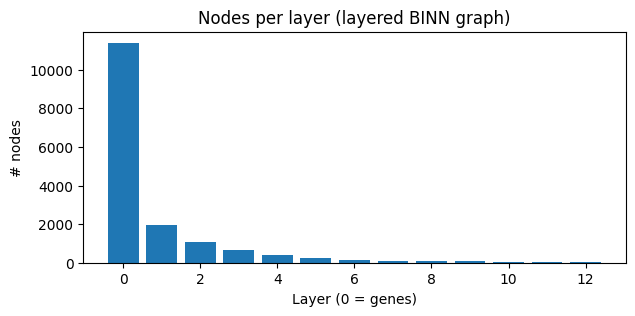

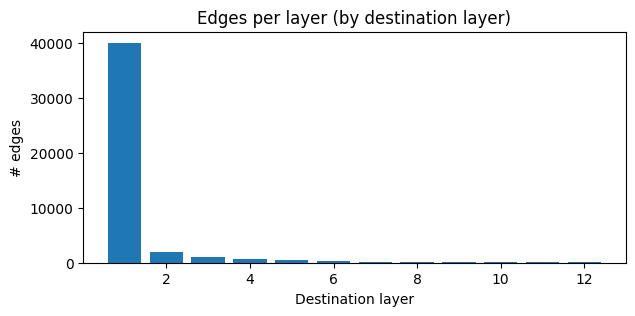

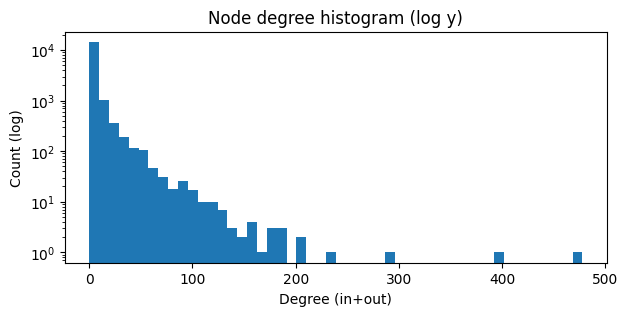

In [7]:
# === 5) Visualize layered structure (nodes per layer, edges per layer) ===
import matplotlib.pyplot as plt

if "layer" in node_layered.columns:
    layer_counts = node_layered.groupby("layer")["layered_id"].count().sort_index()
    plt.figure(figsize=(7,3))
    plt.bar(layer_counts.index.astype(int), layer_counts.values)
    plt.xlabel("Layer (0 = genes)")
    plt.ylabel("# nodes")
    plt.title("Nodes per layer (layered BINN graph)")
    plt.show()

    # edges per layer (by destination layer)
    if "layer" in node_layered.columns:
        dst_layers = node_layered.set_index("layered_id").loc[edge_index[1].cpu().numpy(), "layer"].values
        uniq, cnt = np.unique(dst_layers, return_counts=True)
        plt.figure(figsize=(7,3))
        plt.bar(uniq.astype(int), cnt)
        plt.xlabel("Destination layer")
        plt.ylabel("# edges")
        plt.title("Edges per layer (by destination layer)")
        plt.show()

# Degree histogram (undirected view)
deg = out_deg + in_deg
plt.figure(figsize=(7,3))
plt.hist(deg, bins=50)
plt.yscale("log")
plt.xlabel("Degree (in+out)")
plt.ylabel("Count (log)")
plt.title("Node degree histogram (log y)")
plt.show()


In [8]:
# === 6) Draw a small subgraph near the root (for sanity) ===
# Large graphs are unreadable when fully plotted; we sample a neighborhood around the root.
import matplotlib.pyplot as plt

if root_idx is None:
    print("No explicit root/output node found in node_table_layered.csv. Skipping subgraph draw.")
else:
    GR = G.reverse(copy=False)

    def sample_neighborhood(graph, start, max_nodes=200, max_depth=4):
        visited = {start}
        frontier = [start]
        depth = 0
        while frontier and len(visited) < max_nodes and depth < max_depth:
            nxt = []
            for u in frontier:
                for v in graph.neighbors(u):
                    if v not in visited:
                        visited.add(v)
                        nxt.append(v)
                        if len(visited) >= max_nodes:
                            break
                if len(visited) >= max_nodes:
                    break
            frontier = nxt
            depth += 1
        return visited

    nodes_sample = sample_neighborhood(GR, root_idx, max_nodes=250, max_depth=5)
    SG = UG.subgraph(nodes_sample).copy()

    print("Sampled subgraph nodes:", SG.number_of_nodes(), "edges:", SG.number_of_edges())

    # Node colors by type if available
    node_type = dict(zip(node_layered["layered_id"].astype(int), node_layered["node_type"].astype(str)))
    colors = []
    for n in SG.nodes():
        t = node_type.get(n, "other")
        if t == "gene":
            colors.append("tab:blue")
        elif t.lower() in ["output","root","y","out"]:
            colors.append("tab:red")
        else:
            colors.append("tab:green")

    plt.figure(figsize=(7,7))
    pos = nx.spring_layout(SG, seed=1)
    nx.draw_networkx_nodes(SG, pos, node_size=35, node_color=colors, alpha=0.8)
    nx.draw_networkx_edges(SG, pos, width=0.3, alpha=0.4)
    plt.title("Sample subgraph near root (undirected view)")
    plt.axis("off")
    plt.show()


No explicit root/output node found in node_table_layered.csv. Skipping subgraph draw.


In [9]:
# === 7) Build a PyG dataset (one graph per patient) ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

SEED = 42
VAL_FRAC = 0.2

# For a fast sanity check, you can limit the number of samples.
# Set to None to use all samples.
MAX_SAMPLES = 256

# Standardize gene expression? (train-only fit)
STANDARDIZE_X = True

# Map expression gene names -> layered gene node ids
gene_rows = node_layered.query("node_type=='gene' and layer==0")[["orig_name","layered_id"]]
gene_to_layered = dict(zip(gene_rows["orig_name"].astype(str), gene_rows["layered_id"].astype(int)))

missing_genes = [g for g in expr.index.astype(str).tolist() if g not in gene_to_layered]
if missing_genes:
    print("WARNING: genes in expression not found in graph:", len(missing_genes))
    print("Example:", missing_genes[:10])

gene_map = torch.tensor([gene_to_layered[g] for g in expr.index.astype(str)], dtype=torch.long)

# Build sample matrix (n_samples, n_genes)
X_full = expr.T.values  # samples x genes (numpy)
y_np = y.numpy()

# Optionally subsample for speed (stratified)
if MAX_SAMPLES is not None and X_full.shape[0] > int(MAX_SAMPLES):
    rng = np.random.default_rng(SEED)
    # stratified sample indices
    idx0 = np.where(y_np == 0)[0]
    idx1 = np.where(y_np == 1)[0]
    n0 = int(MAX_SAMPLES * (len(idx0) / len(y_np)))
    n1 = int(MAX_SAMPLES) - n0
    pick0 = rng.choice(idx0, size=min(n0, len(idx0)), replace=False)
    pick1 = rng.choice(idx1, size=min(n1, len(idx1)), replace=False)
    pick = np.concatenate([pick0, pick1])
    rng.shuffle(pick)
    X_full = X_full[pick]
    y_np = y_np[pick]
    print("Subsampled to:", X_full.shape[0], "samples")

idx = np.arange(X_full.shape[0])
train_idx, val_idx = train_test_split(idx, test_size=VAL_FRAC, random_state=SEED, stratify=y_np)

# Standardize (fit on train only)
if STANDARDIZE_X:
    scaler = StandardScaler()
    X_train_np = scaler.fit_transform(X_full[train_idx])
    X_val_np   = scaler.transform(X_full[val_idx])
else:
    X_train_np = X_full[train_idx]
    X_val_np   = X_full[val_idx]

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_val   = torch.tensor(X_val_np,   dtype=torch.float32)
y_train = torch.tensor(y_np[train_idx], dtype=torch.long)
y_val   = torch.tensor(y_np[val_idx],   dtype=torch.long)

print("X_train:", tuple(X_train.shape), "X_val:", tuple(X_val.shape))

# Choose whether to use directed or undirected edges for the sanity check.
USE_UNDIRECTED = True
edge_index_use = edge_index_undirected if USE_UNDIRECTED else edge_index_directed

class TCGAGraphDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, edge_index, num_nodes, gene_map):
        self.X = X
        self.y = y
        self.edge_index = edge_index
        self.num_nodes = int(num_nodes)
        self.gene_map = gene_map

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        # Node features: (num_nodes, 1). Genes get expression values, everything else starts at 0.
        x = torch.zeros((self.num_nodes, 1), dtype=torch.float32)
        x[self.gene_map, 0] = self.X[i]
        return Data(x=x, edge_index=self.edge_index, y=self.y[i].view(1))

train_ds = TCGAGraphDataset(X_train, y_train, edge_index_use, num_nodes, gene_map)
val_ds   = TCGAGraphDataset(X_val,   y_val,   edge_index_use, num_nodes, gene_map)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

batch0 = next(iter(train_loader))
print(batch0)
print("batch0.x:", tuple(batch0.x.shape), "batch0.edge_index:", tuple(batch0.edge_index.shape), "batch0.y:", tuple(batch0.y.shape))


Subsampled to: 256 samples
X_train: (204, 11403) X_val: (52, 11403)
DataBatch(x=[130264, 1], edge_index=[2, 719280], y=[8], batch=[130264], ptr=[9])
batch0.x: (130264, 1) batch0.edge_index: (2, 719280) batch0.y: (8,)


In [10]:
# === 8) Define vanilla PyG models ===
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_add_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

class VanillaGCN(nn.Module):
    def __init__(self, in_dim=1, hidden=32, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        assert num_layers >= 2
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden, hidden))
        self.dropout = float(dropout)
        self.lin = nn.Linear(hidden, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        hg = global_add_pool(x, batch)  # graph-level embedding
        return self.lin(hg)

class VanillaGAT(nn.Module):
    def __init__(self, in_dim=1, hidden=32, num_layers=2, dropout=0.2, heads=2, num_classes=2):
        super().__init__()
        assert num_layers >= 2
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_dim, hidden, heads=heads, concat=False, dropout=dropout))
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden, hidden, heads=heads, concat=False, dropout=dropout))
        self.dropout = float(dropout)
        self.lin = nn.Linear(hidden, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        hg = global_add_pool(x, batch)
        return self.lin(hg)

# Quick forward pass sanity
gcn = VanillaGCN(hidden=32, num_layers=2).to(device)
gat = VanillaGAT(hidden=32, num_layers=2).to(device)
batch0 = batch0.to(device)

with torch.no_grad():
    out_gcn = gcn(batch0)
    out_gat = gat(batch0)
print("out_gcn:", tuple(out_gcn.shape), "out_gat:", tuple(out_gat.shape))


device: cpu
out_gcn: (8, 2) out_gat: (8, 2)


In [11]:
# === 9) Training / evaluation loop (simple) ===
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

def run_train(model, train_loader, val_loader, *, lr=1e-3, weight_decay=1e-5, epochs=20):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))
    loss_fn = nn.CrossEntropyLoss()

    hist = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(1, int(epochs)+1):
        model.train()
        tloss = 0.0
        n = 0
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch)
            # batch.y shape: (batch_size, 1) -> squeeze
            loss = loss_fn(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            tloss += loss.item() * batch.num_graphs
            n += batch.num_graphs
        tloss /= max(1, n)

        # Eval
        model.eval()
        vloss = 0.0
        probs = []
        ys = []
        n = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                logits = model(batch)
                loss = loss_fn(logits, batch.y.view(-1))
                vloss += loss.item() * batch.num_graphs
                n += batch.num_graphs

                p = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
                probs.append(p)
                ys.append(batch.y.view(-1).detach().cpu().numpy())

        vloss /= max(1, n)
        probs = np.concatenate(probs)
        ys = np.concatenate(ys)
        try:
            auc = roc_auc_score(ys, probs)
        except Exception:
            auc = float("nan")

        hist["train_loss"].append(tloss)
        hist["val_loss"].append(vloss)
        hist["val_auc"].append(auc)

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | train_loss={tloss:.4f} val_loss={vloss:.4f} val_auc={auc:.3f}")

    return hist



/home/maani/miniconda3/envs/nilooenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# === 10) Run: Vanilla GCNConv ===
gcn = VanillaGCN(hidden=32, num_layers=2, dropout=0.2).to(device)
hist_gcn = run_train(gcn, train_loader, val_loader, lr=1e-3, weight_decay=1e-5, epochs=25)


Epoch 01 | train_loss=21.3746 val_loss=8.3934 val_auc=0.500
Epoch 05 | train_loss=9.0676 val_loss=10.2791 val_auc=0.500
Epoch 10 | train_loss=3.0091 val_loss=21.7519 val_auc=0.438
Epoch 15 | train_loss=2.8501 val_loss=4.2455 val_auc=0.471
Epoch 20 | train_loss=3.2710 val_loss=7.4866 val_auc=0.490
Epoch 25 | train_loss=6.3728 val_loss=5.2796 val_auc=0.500


In [13]:
# === 11) Run: Vanilla GATConv ===
gat = VanillaGAT(hidden=32, num_layers=2, dropout=0.2, heads=2).to(device)
hist_gat = run_train(gat, train_loader, val_loader, lr=1e-3, weight_decay=1e-5, epochs=25)


Epoch 01 | train_loss=11.2269 val_loss=8.2914 val_auc=0.500
Epoch 05 | train_loss=4.3407 val_loss=7.2900 val_auc=0.500
Epoch 10 | train_loss=4.2460 val_loss=4.1292 val_auc=0.417
Epoch 15 | train_loss=3.4735 val_loss=4.4682 val_auc=0.458
Epoch 20 | train_loss=3.1501 val_loss=2.8890 val_auc=0.500
Epoch 25 | train_loss=3.5697 val_loss=5.1309 val_auc=0.500


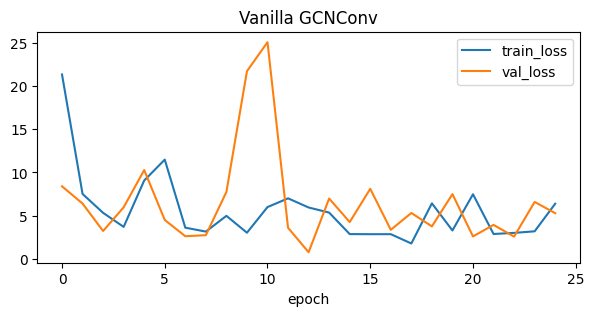

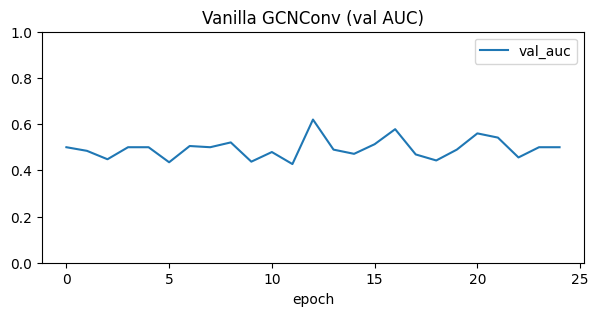

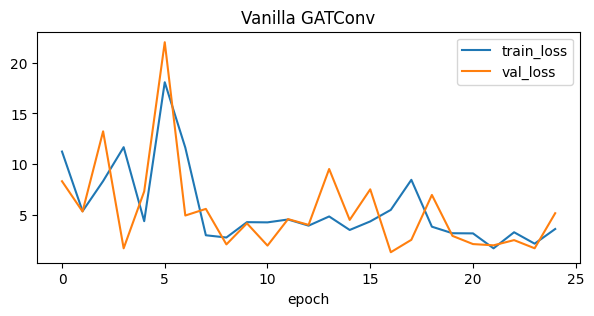

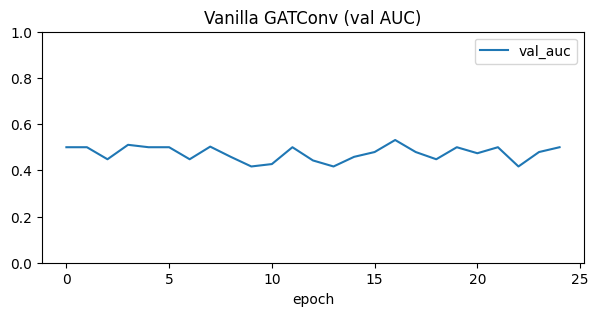

In [14]:
# === 12) Plot training curves ===
import matplotlib.pyplot as plt

def plot_hist(hist, title):
    plt.figure(figsize=(7,3))
    plt.plot(hist["train_loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,3))
    plt.plot(hist["val_auc"], label="val_auc")
    plt.title(title + " (val AUC)")
    plt.xlabel("epoch")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.show()

plot_hist(hist_gcn, "Vanilla GCNConv")
plot_hist(hist_gat, "Vanilla GATConv")


## How to interpret this notebook

If both models:

- run a forward pass (no shape errors)
- show **train loss decreasing**
- produce a **val AUC that moves away from ~0.5**

then:

✅ your **graph artifacts** are usable with PyG  
✅ your **gene-to-node mapping** is correct  
✅ your data pipeline is not fundamentally broken

If they **still** get stuck at chance, the likely causes are:
- label issue / sample alignment issue
- too much class imbalance
- feature scaling
- graph is extremely disconnected (check reachability + components above)
- your task is genuinely hard on this representation

Next step would be to rerun with:
- `USE_UNDIRECTED=False` (directed edges)
- fewer / more GNN layers
- StandardScaler on X (train-only fit)
- smaller graph neighborhood (subgraph) to see if training improves
